In [9]:
from src.pipelines.tiresia_pipeline import run_tiresia_pipeline

txt_path = "data\\TIRESIA\\ci2c01126_si_002.txt"
ti_res = run_tiresia_pipeline(txt_path)

print("Accuracy:", ti_res.accuracy)
print(ti_res.report)


[12:06:21] SMILES Parse Error: syntax error while parsing: SMILES
[12:06:21] SMILES Parse Error: Failed parsing SMILES 'SMILES' for input: 'SMILES'


LABEL
1    160
0     74
Name: count, dtype: int64
Accuracy: 0.723404255319149
              precision    recall  f1-score   support

           0       0.67      0.27      0.38        15
           1       0.73      0.94      0.82        32

    accuracy                           0.72        47
   macro avg       0.70      0.60      0.60        47
weighted avg       0.71      0.72      0.68        47

Accuracy: 0.723404255319149
              precision    recall  f1-score   support

           0       0.67      0.27      0.38        15
           1       0.73      0.94      0.82        32

    accuracy                           0.72        47
   macro avg       0.70      0.60      0.60        47
weighted avg       0.71      0.72      0.68        47



c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


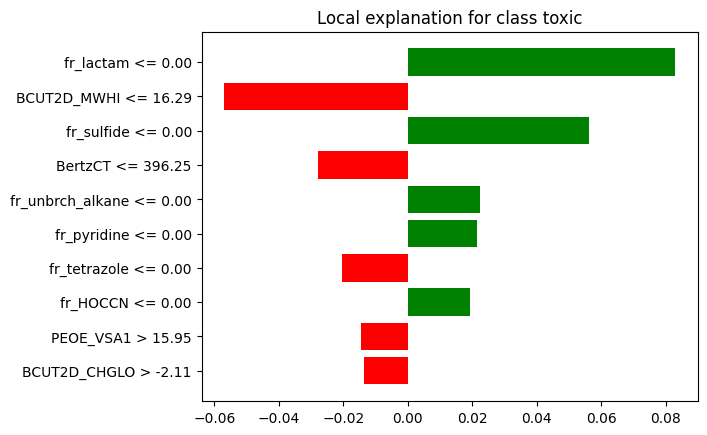

In [ ]:
# Ejemplo de explicación local con LIME (mostrar solo las 10 principales)
idx = 0
instance = ti_res.X_test.iloc[idx].values
# Pedimos únicamente las 10 características más importantes para que el gráfico sea legible
lime_exp = ti_res.lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=ti_res.model.predict_proba,
    num_features=10,
)

# Mostrar la figura (matplotlib)
fig = lime_exp.as_pyplot_figure()
import matplotlib.pyplot as plt
plt.close(fig)
fig


PermutationExplainer explainer: 48it [00:23,  1.69it/s]                        



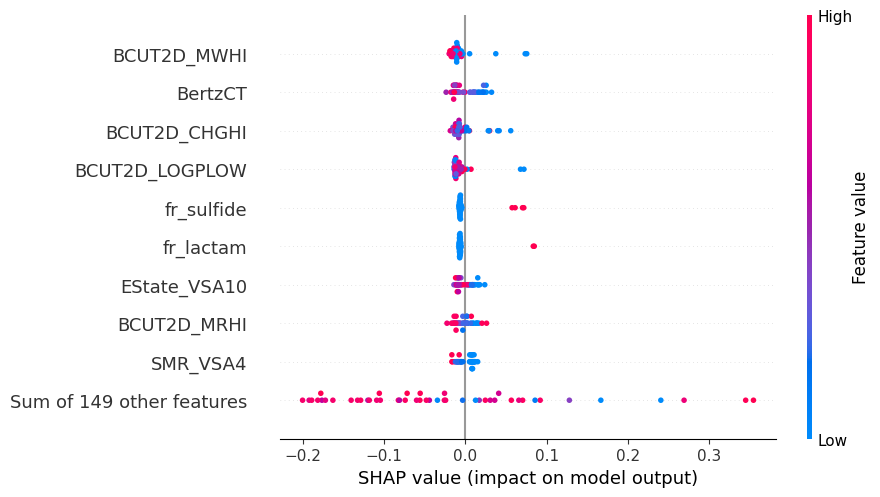

In [3]:
# SHAP local
import shap

shap_values = ti_res.shap_explainer(ti_res.X_test)
# tomar valores locales para el índice elegido
shap_local = shap_values[..., idx]
shap.plots.beeswarm(shap_local)


In [ ]:
# LLM: generar explicación usando el wrapper de Gemini
from src.llm.gemini_explainer import explicar_con_gemini

# en el prompt maestro se hardcodean los descriptores molecultares, debería agregar un parámetro para pasarlos dinámicamente y que se ajuste al modelo 
texto = explicar_con_gemini(
    shap_local=shap_local,
    shap_global=shap_values,
    lime_exp=lime_exp,
    pred=ti_res.y_pred[idx],
    task_type="clasificación TIRESIA",
    domain="ia",
    expertise_level="beginner",
)
print(texto)


¡Excelente! Entendido. Para poder darte la explicación más clara y útil, primero necesito confirmar los datos de la predicción que te gustaría analizar.

**Predicción del modelo:** 1
**Nivel de expertise del usuario:** beginner
**Dominio del usuario:** ia

Vamos a analizar qué propiedades químicas están empujando a esta molécula a ser clasificada como **TIRESIA Clase 1**. Como tu dominio es IA y tu nivel es principiante, me enfocaré en el significado químico de los factores sin entrar en los detalles técnicos de cómo funciona SHAP.

---

**Análisis de la Predicción para TIRESIA Clase 1 (Molécula Específica)**

Tu modelo de IA predice que esta molécula pertenece a la **Clase 1 de TIRESIA**. Para entender por qué el modelo llegó a esta conclusión, veamos cuáles de sus características químicas fueron las más influyentes:

1.  **La Polaridad de la Molécula (piPC09):**
    *   **¿Qué es?** La polaridad indica qué tan bien una molécula se mezcla con el agua (polar) o con sustancias oleosas (